In [1]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import time
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
#import csv
import os.path
from os import path
%matplotlib inline

In [2]:
cfmin, cfmax, cfN = 50*b2.Hz, 3*b2.kHz, 100
# 72 chemosensors, but changing to 100 leads to finer frequencies and the network still works
# 50 to 3000 Hz because normal human speech is within these frequencies
cf = b2h.erbspace(cfmin, cfmax, cfN)
sound = b2h.loadsound('harvard_sentence.wav')
sound.save('harvard_sentence.wav')

sound = sound[13000:330000]
gfb = b2h.Gammatone(sound, cf)
ihc = b2h.FunctionFilterbank(gfb, lambda x: 3*clip(x, 0, Inf)**(1.0/3.0))
# Leaky integrate-and-fire model with noise and refractoriness
eqs = '''
dv/dt = (I-v)/(1*ms)+0.2*xi*(2/(1*ms))**.5 : 1 (unless refractory)
I : 1
'''
G = b2h.FilterbankGroup(ihc, 'I', eqs, reset='v=0', threshold='v>1', refractory=5*b2.ms)

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


Text(0.5,0,'Time (index)')

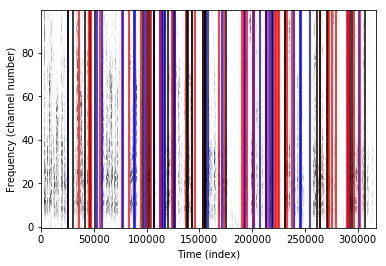

In [3]:
X = np.abs(gfb.process().T)
#X[30:,:]*=3
X = np.log(X+.01)
X += X.min()
plt.imshow(X,aspect='auto', origin='lower left')

xcoords = np.array([500,750,1050,1250, 1600,1800,2000,2500,2800,3000])*8
# change xcoords2 to be after xcoords.max +1000 
xcoords2 = np.random.randint(3000*8+1000,317001, size=100)
testDataName = "testOdorsList3.txt"
# check if testDataName exists. If it exists, load it. If it doesn't exist, continue with creating the file as below
if path.exists(testDataName):
    xcoords2 = np.loadtxt(testDataName)
    print(testDataName+" exists")
'''
with open(testDataName,"r") as csv_file:
    reader = csv.reader(csvfile, delimiter=' ')
    for item in xcoords2:
        file.read('%s,'%item)
'''        
colors = ['r','k','b','r','k','b','r','k','b','r']*10
for xc,c in zip(xcoords2,colors):
    plt.axvline(x=xc, label='line at x = {}'.format(xc), c=c)

'''
scale_factor = 72/5000
plt.ylim(0,72)
'''
#locs, labels = yticks()
#xticks()
plt.set_cmap('gray_r')
plt.ylabel('Frequency (channel number)')
plt.xlabel('Time (index)')

In [4]:
from lib import epl 

scale = 10
#scale = 33.6
trainingOdors = X[:,xcoords[:]].T/X.max()*scale
trainingOdors = trainingOdors.astype(np.int64)

testOdors = X[:,xcoords2[:]].T/X.max()*scale
testOdors = testOdors.astype(np.int64)


nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1,nGammaPerOdor = 10); 
    # changed nGammaPerOdor from 5 to 10
    epl.GClayer.invokeNeurogenesis();
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i%10==0 and i!=0):
        print(str(i) + " odors tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")

#Readout
# has summary of a lot of the results
# find structure of sMatrix and summarize the performance for a particular run

#Plots
#plots.plotFigure4a(epl.gammaCode); 
#plots.plotFigure4b(sMatrix); 
#plots.plotFigure4d(epl.gammaCode, sMatrix);

Number of odors to train = 10
Number of odors to test = 100
Training odor 1
Training odor 2
Training odor 3
Training odor 4
Training odor 5
Training odor 6
Training odor 7
Training odor 8
Training odor 9
Training odor 10
10 odors tested
20 odors tested
30 odors tested
40 odors tested
50 odors tested
60 odors tested
70 odors tested
80 odors tested
90 odors tested
Simulation Duration = 6222.68700004s


In [8]:
sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  


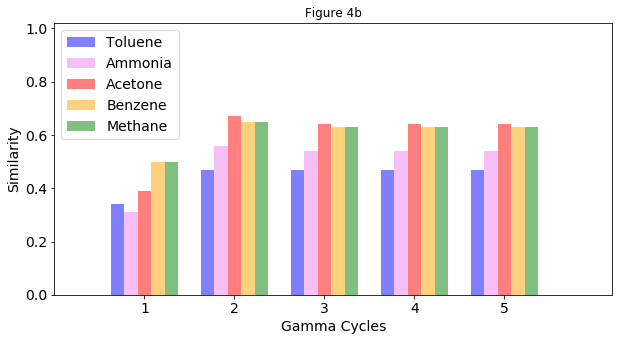

In [9]:
plots.plotFigure4b(sMatrix); 

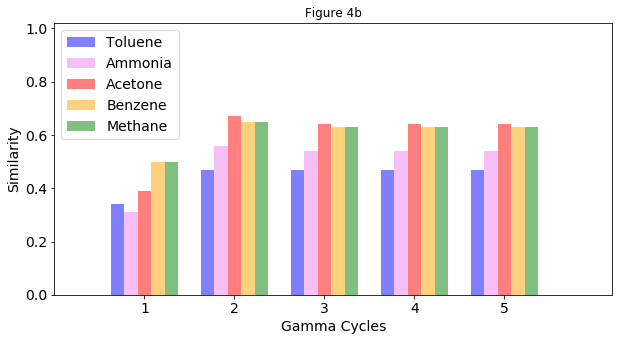

In [11]:
plt.figure(3); 
sampleNumbers = [0, 0, 0, 0, 9, 9, 0, 0, 0, 9]; 
fsize=12;
fsize2=16;  
plt.subplots_adjust(hspace=0.45, wspace=0.25);
plotTitles = ['Sound 1', 'Sound 2', 'Sound 3', 'Sound 4', 'Sound 5', '', 'Ethylene', 'Methane', 'Methanol', 'Toluene'];
#Order of stim presentation in simulation: 
#Toluene, Benzene, Methane, Carbon Monoxide, Ammonia, Acetone, Acetaldehyde, Methanol, Butanol, Ethylene
rasterOrderOdors = [6, 5, 4, 1, 8, 3, 9, 2, 7, 0];         #alphabetical ordering for plots
nMCs = len(gammaCode[0]); 
nOdors = 10; 
nGamma = 5; 
nTestPerOdor = len(sMatrix)/(nOdors*nGamma);            
for i in range(0,10):
    #Raster plot
    plt.subplot(5, 4, 2*i+1);
    odorID = rasterOrderOdors[i];  
    sniffID = nOdors*2 + nTestPerOdor*odorID + sampleNumbers[odorID];
    for j in range(0, nGamma): 
        gammaID = nGamma*sniffID + j; 
        for k in range(0, nMCs):
            if(gammaCode[gammaID][k] != 0): 
                spikeTime = 20 - gammaCode[gammaID][k] + 40*j;
                plt.scatter(spikeTime, k, color='k', s=2); 
    plt.title(plotTitles[i], fontsize=fsize2); 
    plt.yticks([0, 20, 40, 60], fontsize=fsize);
    if(i>=8): 
        plt.xticks([0, 40, 80, 120, 160, 200], fontsize=fsize);
        plt.xlabel('Timesteps', fontsize=fsize2);
        plt.ylabel('MC Index', fontsize=fsize2); 
    else:
        plt.xticks([]);
    #Similarity plot
    plt.subplot(5, 4, 2*i+2);
    bar_y = []; 
    gammaID = odorID*nTestPerOdor*nGamma + sampleNumbers[odorID]*nGamma; 
    for j in range(0, 5): 
        bar_y.append(sMatrix[gammaID+j][odorID]); 
    plt.bar([40, 80, 120, 160, 200], bar_y, color='black', width=10.0);
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], fontsize=fsize);
    plt.ylim([0.0, 1.02])
    plt.xlim([0, 240])
    if(i>=8): 
        plt.xticks([40, 80, 120, 160, 200], [1, 2, 3, 4, 5], fontsize=fsize);
        plt.xlabel('Gamma Cycles', fontsize=fsize2);
        plt.ylabel('Similarity', fontsize=fsize2); 
    else:
        plt.xticks([]);
plt.show() 


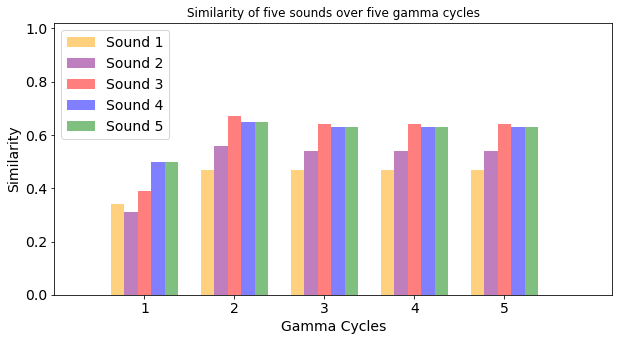

In [15]:
bar1_x, bar2_x, bar3_x, bar4_x, bar5_x = [], [], [], [], [];      
bar1_y, bar2_y, bar3_y, bar4_y, bar5_y = [], [], [], [], [];      
nGamma = 5; 
testOdorID = 0;              #sniff ID of test odor 
for i in range(0, nGamma):
    bar1_y.append(sMatrix[testOdorID+i][0]);
    bar2_y.append(sMatrix[testOdorID+i][4]);
    bar3_y.append(sMatrix[testOdorID+i][5]);
    bar4_y.append(sMatrix[testOdorID+i][1]);
    bar5_y.append(sMatrix[testOdorID+i][2]);
w = 0.15        #width of bars
fsize = 14;
xticks = []
xtick_labels = []
for i in range(0, 5):    
    bar1_x.append(i-2*w);
    bar2_x.append(i-w);
    bar3_x.append(i);
    bar4_x.append(i+w); 
    bar5_x.append(i+2*w);     
    xticks.append(i)
    xtick_labels.append(str(i+1))
plt.figure(2, figsize=(10, 5))
fig = plt.subplot(111)
opacity = 0.5; 
bar1 = plt.bar(bar1_x, bar1_y, width = w, color = 'orange', alpha = opacity, align='center')
bar2 = plt.bar(bar2_x, bar2_y, width = w, color = 'purple', alpha = opacity, align='center')
bar3 = plt.bar(bar3_x, bar3_y, width = w, color = 'red', alpha = opacity, align='center')
bar4 = plt.bar(bar4_x, bar4_y, width = w, color = 'blue', alpha=opacity, align='center')
bar5 = plt.bar(bar5_x, bar5_y, width = w, color = 'green', alpha=opacity, align='center')
plt.xlim(-1, len(bar1_x)+0.2)
plt.ylim(0, 1.02)
plt.xticks(xticks, xtick_labels, fontsize=fsize)
plt.yticks(fontsize=fsize); 
fig.legend( (bar1, bar2, bar3, bar4, bar5), ('Sound 1', 'Sound 2', 'Sound 3', 'Sound 4', 'Sound 5'), loc = 'upper left', fontsize=fsize)
plt.ylabel('Similarity', fontsize=fsize); 
plt.xlabel('Gamma Cycles', fontsize=fsize); 
plt.title("Similarity of five sounds over five gamma cycles")
plt.show()